In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np
import re
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut
import time

# Atur agar semua kolom terlihat
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_seq_items', None)
pd.options.display.max_rows = None
pd.options.display.max_columns = None 


In [2]:
df = pd.read_csv("airbnb-listings-us-cleaned.csv", low_memory=False)

In [3]:
df.head()

,Last Scraped,Host Since,Host Response Time,Host Response Rate,Host Neighbourhood,Host Total Listings Count,Neighbourhood,City,State,Zipcode,Latitude,Longitude,Property Type,Room Type,Accommodates,Bathrooms,Bedrooms,Beds,Bed Type,Amenities,Price,Cleaning Fee,Guests Included,Extra People,Minimum Nights,Maximum Nights,Calendar Updated,Availability 30,Availability 60,Availability 90,Availability 365,Calendar last Scraped,Number of Reviews,Review Scores Rating,Review Scores Accuracy,Review Scores Cleanliness,Review Scores Checkin,Review Scores Communication,Review Scores Location,Review Scores Value,Cancellation Policy,Calculated host listings count,Reviews per Month,Wireless Internet,Heating,Kitchen,Essentials,TV,Smoke detector,Shampoo,Internet,Washer,Dryer
0,2017-05-02,2014-11-22 00:00:00,within an hour,100.0,Woodland Hills/Warner Center,1,Woodland Hills,Los Angeles,CA,91364,34.147756,-118.591338,Apartment,Private room,2.0,1,1,1,Real Bed,"TV,Wireless Internet,Air conditioning,Free parking on premises,Hot tub,Heating,Smoke detector,Carbon monoxide detector,Essentials,Shampoo",150.0,25.0,1.0,0.0,1.0,1125.0,29 months ago,30.0,60.0,90.0,365.0,2017-05-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,flexible,1.0,0.00,True,True,False,True,True,True,True,True,False,False
1,2017-05-03,2016-02-02 00:00:00,within a day,100.0,Woodland Hills/Warner Center,1,Woodland Hills,Los Angeles,CA,91364,34.164597,-118.600512,House,Entire home/apt,8.0,3,4,4,Real Bed,"Wireless Internet,Air conditioning,Pool,Kitchen,Free parking on premises,Pets allowed,Indoor fireplace,Heating,Family/kid friendly,Washer,Dryer,Smoke detector,Carbon monoxide detector,First aid kit,Safety card,Essentials,Shampoo,Hangers,Hair dryer,Iron,Laptop friendly workspace,TV",175.0,150.0,8.0,25.0,2.0,1125.0,today,9.0,19.0,28.0,28.0,2017-05-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,flexible,1.0,0.00,True,True,True,True,True,True,True,True,True,True
2,2017-05-03,2016-11-22 00:00:00,within a few hours,100.0,Woodland Hills/Warner Center,1,Woodland Hills,Los Angeles,CA,91367,34.183150,-118.645064,Guesthouse,Entire home/apt,3.0,1,1,1,Real Bed,"TV,Wireless Internet,Air conditioning,Kitchen,Free parking on premises,Heating,Family/kid friendly,Washer,Dryer,Smoke detector,Carbon monoxide detector,Essentials,Hangers,Laptop friendly workspace",79.0,55.0,1.0,25.0,2.0,26.0,yesterday,30.0,60.0,90.0,90.0,2017-05-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,flexible,1.0,0.00,True,True,True,True,True,True,False,True,True,True
3,2017-05-03,2011-04-13 00:00:00,within a few hours,100.0,Woodland Hills/Warner Center,2,Woodland Hills,Woodland Hills,CA,91364,34.148594,-118.596684,Other,Entire home/apt,2.0,1,1,1,Real Bed,"TV,Cable TV,Wireless Internet,Air conditioning,Kitchen,Free parking on premises,Heating,Washer,Dryer,Smoke detector,Carbon monoxide detector,First aid kit,Fire extinguisher,Essentials,Shampoo,Hangers,Hair dryer,Iron,translation missing: en.hosting_amenity_49,translation missing: en.hosting_amenity_50",175.0,100.0,1.0,0.0,2.0,5.0,2 weeks ago,12.0,42.0,72.0,72.0,2017-05-03,2.0,100.0,10.0,10.0,10.0,10.0,10.0,10.0,strict,2.0,0.16,True,True,True,True,True,True,True,True,True,True
4,2017-05-03,2015-01-03 00:00:00,within an hour,100.0,Studio City,36,Woodland Hills,Los Angeles,CA,91367,34.174245,-118.605876,Townhouse,Entire home/apt,6.0,2,3,4,Real Bed,"TV,Cable TV,Internet,Wireless Internet,Air conditioning,Pool,Kitchen,Free parking on premises,Pets allowed,Hot tub,Indoor fireplace,Heating,Family/kid friendly,Suitable for events,Washer,Dryer,Smoke detector,First aid kit,Safety card,Fire extinguisher,Essentials,Hangers,Hair dryer,Iron,Laptop friendly workspace",450.0,200.0,6.0,50.0,3.0,1125.0,today,26.0,56.0,86.0,361.0,2017-05-03,8.0,95.0,9.0,10.0,10.0,10.0,9.0,10.0,moderate,29.0,0.79,True,True,True,True,True,True,False,True,True,True


In [4]:
df[(df["Review Scores Rating"] <= 10) & (df["Review Scores Rating"] >= 0) & (df["Number of Reviews"] > 0)][["Review Scores Rating", "Number of Reviews", "Property Type", "Room Type", "Accommodates", "Bathrooms", "Bedrooms", "Beds", "Bed Type"]].head(20)


,Review Scores Rating,Number of Reviews,Property Type,Room Type,Accommodates,Bathrooms,Bedrooms,Beds,Bed Type


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132581 entries, 0 to 132580
Data columns (total 53 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   Last Scraped                    132581 non-null  object 
 1   Host Since                      132581 non-null  object 
 2   Host Response Time              132581 non-null  object 
 3   Host Response Rate              132581 non-null  float64
 4   Host Neighbourhood              132581 non-null  object 
 5   Host Total Listings Count       132581 non-null  int64  
 6   Neighbourhood                   132581 non-null  object 
 7   City                            132581 non-null  object 
 8   State                           132581 non-null  object 
 9   Zipcode                         132581 non-null  int64  
 10  Latitude                        132581 non-null  float64
 11  Longitude                       132581 non-null  float64
 12  Property Type   

C:\Users\USER\AppData\Local\Temp\ipykernel_27372\4114846314.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


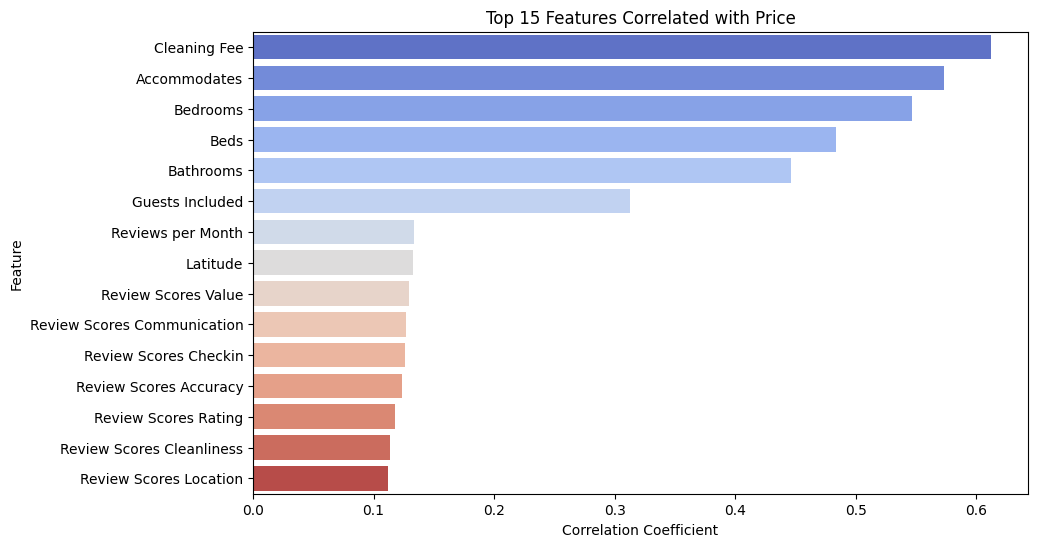

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Pilih fitur numerik
numerical_features = [
    "Host Response Rate", "Host Total Listings Count", "Zipcode", "Latitude", "Longitude",
    "Accommodates", "Bathrooms", "Bedrooms", "Beds", "Cleaning Fee", "Guests Included",
    "Extra People", "Minimum Nights", "Maximum Nights", "Availability 30", "Availability 60",
    "Availability 90", "Availability 365", "Number of Reviews", "Review Scores Rating",
    "Review Scores Accuracy", "Review Scores Cleanliness", "Review Scores Checkin",
    "Review Scores Communication", "Review Scores Location", "Review Scores Value",
    "Calculated host listings count", "Reviews per Month"
]

# Filter hanya fitur numerik + target
df_numeric = df[numerical_features + ["Price"]]

# Hitung korelasi dengan target "Price"
price_corr = df_numeric.corr()["Price"].drop("Price").abs().sort_values(ascending=False)

# Ambil top 12 fitur dengan korelasi tertinggi terhadap "Price"
top_features = price_corr.head(15)

# Plot dengan seaborn
plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_features.values,
    y=top_features.index,
    palette="coolwarm"
)

plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")
plt.title("Top 15 Features Correlated with Price")
plt.show()


C:\Users\USER\AppData\Local\Temp\ipykernel_27372\2477687630.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


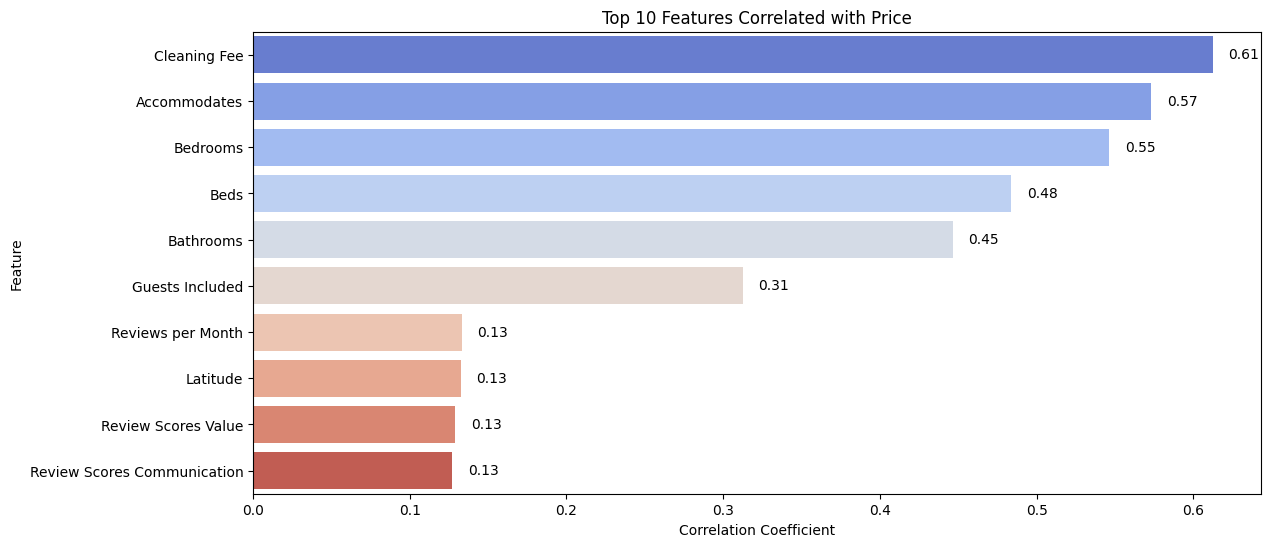

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Pilih fitur numerik
numerical_features = [
    "Host Response Rate", "Host Total Listings Count", "Zipcode", "Latitude", "Longitude",
    "Accommodates", "Bathrooms", "Bedrooms", "Beds", "Cleaning Fee", "Guests Included",
    "Extra People", "Minimum Nights", "Maximum Nights", "Availability 30", "Availability 60",
    "Availability 90", "Availability 365", "Number of Reviews", "Review Scores Rating",
    "Review Scores Accuracy", "Review Scores Cleanliness", "Review Scores Checkin",
    "Review Scores Communication", "Review Scores Location", "Review Scores Value",
    "Calculated host listings count", "Reviews per Month"
]

# Filter hanya fitur numerik + target
df_numeric = df[numerical_features + ["Price"]]

# Hitung korelasi dengan target "Price"
price_corr = df_numeric.corr()["Price"].drop("Price").abs().sort_values(ascending=False)

# Ambil top 15 fitur dengan korelasi tertinggi terhadap "Price"
top_features = price_corr.head(10)

# Plot dengan Seaborn
plt.figure(figsize=(13,6))
ax = sns.barplot(
    x=top_features.values,
    y=top_features.index,
    palette="coolwarm"
)

# Tambahkan nilai korelasi di samping bar
for i, v in enumerate(top_features.values):
    ax.text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=10)  # Geser sedikit ke kanan

plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")
plt.title("Top 10 Features Correlated with Price")
plt.show()


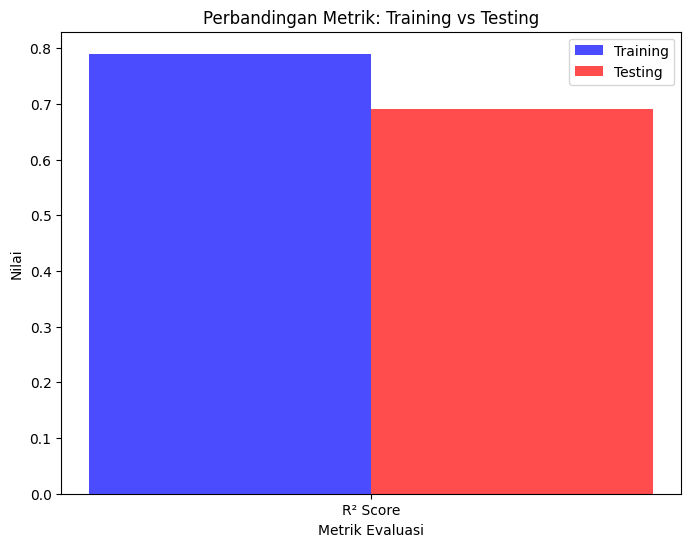

In [29]:
import matplotlib.pyplot as plt

# Contoh nilai metrik
mae_train = 36.68  # MAE pada training set
mae_test = 42.18   # MAE pada testing set

r2_train = 0.79  # R² Score pada training set
r2_test = 0.69   # R² Score pada testing set

rmse_train = 62.28  # RMSE pada training set
rmse_test = 74.57   # RMSE pada testing set

# Plot Bar Chart
labels = ["R² Score"]
train_scores = [r2_train]
test_scores = [r2_test]

x = range(len(labels))

plt.figure(figsize=(8, 6))
plt.bar(x, train_scores, width=0.4, label="Training", color="blue", alpha=0.7)
plt.bar([i + 0.4 for i in x], test_scores, width=0.4, label="Testing", color="red", alpha=0.7)
plt.xticks([i + 0.2 for i in x], labels)

plt.xlabel("Metrik Evaluasi")
plt.ylabel("Nilai")
plt.title("Perbandingan Metrik: Training vs Testing")
plt.legend()
plt.show()


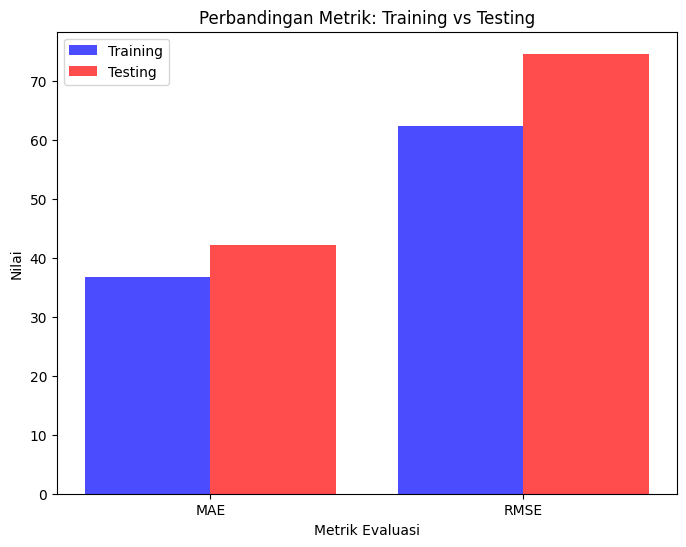

In [30]:
import matplotlib.pyplot as plt

# Contoh nilai metrik
mae_train = 36.68  # MAE pada training set
mae_test = 42.18   # MAE pada testing set

r2_train = 0.79  # R² Score pada training set
r2_test = 0.69   # R² Score pada testing set

rmse_train = 62.28  # RMSE pada training set
rmse_test = 74.57   # RMSE pada testing set

# Plot Bar Chart
labels = ["MAE", "RMSE"]
train_scores = [mae_train, rmse_train]
test_scores = [mae_test, rmse_test]

x = range(len(labels))

plt.figure(figsize=(8, 6))
plt.bar(x, train_scores, width=0.4, label="Training", color="blue", alpha=0.7)
plt.bar([i + 0.4 for i in x], test_scores, width=0.4, label="Testing", color="red", alpha=0.7)
plt.xticks([i + 0.2 for i in x], labels)

plt.xlabel("Metrik Evaluasi")
plt.ylabel("Nilai")
plt.title("Perbandingan Metrik: Training vs Testing")
plt.legend()
plt.show()


C:\Users\USER\AppData\Local\Temp\ipykernel_18924\3395422258.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


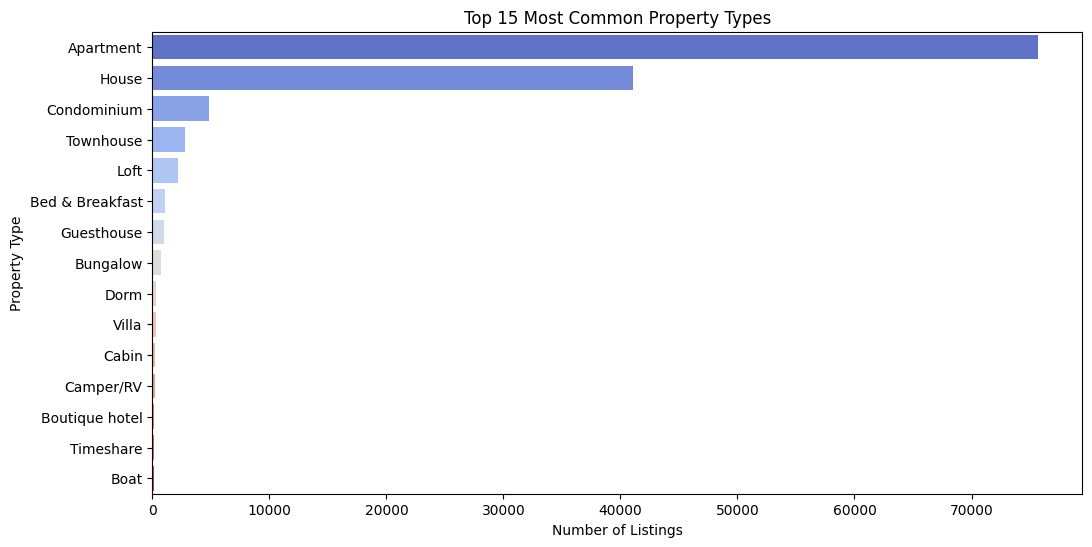

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Hitung jumlah listing berdasarkan Property Type
property_counts = df["Property Type"].value_counts()

# Ambil 15 Property Type dengan jumlah terbanyak
top_15_properties = property_counts.head(15)

# Plot dengan Seaborn
plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_15_properties.values, 
    y=top_15_properties.index, 
    palette="coolwarm"
)

plt.xlabel("Number of Listings")
plt.ylabel("Property Type")
plt.title("Top 15 Most Common Property Types")
plt.show()


In [20]:
df.drop(df[df["Property Type"] == "Other"].index, inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_18924\3649617867.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


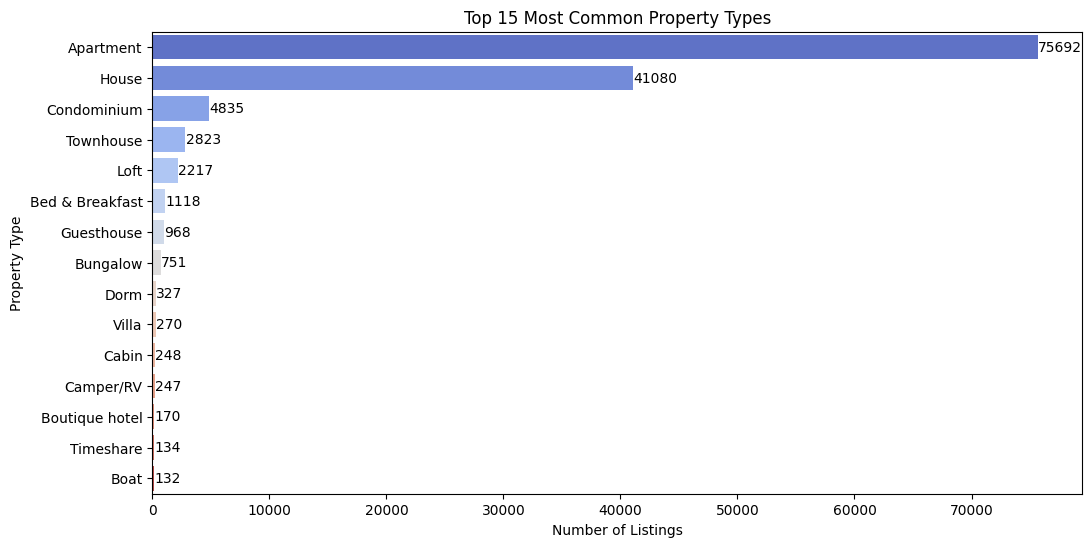

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Hitung jumlah listing berdasarkan Property Type
property_counts = df["Property Type"].value_counts()

# Ambil 15 Property Type dengan jumlah terbanyak
top_15_properties = property_counts.head(15)

# Plot dengan Seaborn
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x=top_15_properties.values, 
    y=top_15_properties.index, 
    palette="coolwarm"
)

# Tambahkan label angka di samping bar
for index, value in enumerate(top_15_properties.values):
    ax.text(value + 10, index, str(value), va='center')  # +10 agar angka tidak menempel

plt.xlabel("Number of Listings")
plt.ylabel("Property Type")
plt.title("Top 15 Most Common Property Types")
plt.show()


C:\Users\USER\AppData\Local\Temp\ipykernel_18924\322613780.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


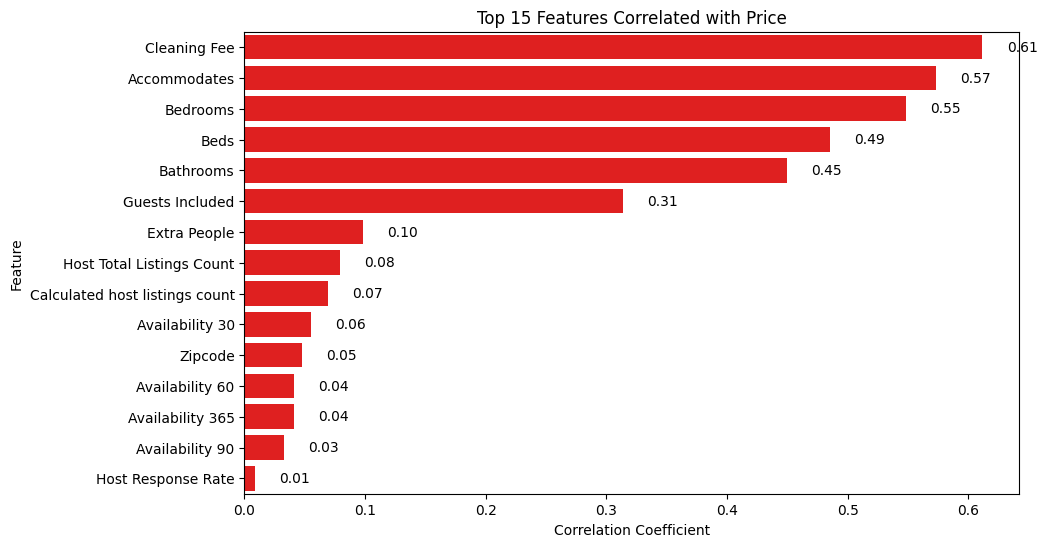

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Hitung korelasi tanpa absolute value
price_corr = df_numeric.corr()["Price"].drop("Price").sort_values(ascending=False)

# Ambil top 15 fitur dengan korelasi tertinggi (termasuk negatif)
top_features = price_corr.head(15)

# Pilih warna berdasarkan nilai korelasi (biru untuk negatif, merah untuk positif)
colors = ["red" if v > 0 else "blue" for v in top_features.values]

# Plot dengan seaborn
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=top_features.values,
    y=top_features.index,
    palette=colors
)

# Tambahkan nilai korelasi di samping bar
for i, v in enumerate(top_features.values):
    ax.text(v + (0.02 if v > 0 else -0.05), i, f"{v:.2f}", va="center", fontsize=10)

plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")
plt.title("Top 15 Features Correlated with Price")
plt.show()
